# Hawkes-process JSCC — vrai train de spikes en entrée/sortie, N aléatoire

Suite de `point_process_jscc.ipynb`, même énoncé (`student_project_point_process_jscc.pdf`),
même canal à jitter gaussien, même contrainte `N_X = N_S`, `R = 1`. Version SNN "au sens
classique" du terme, après discussion sur l'architecture :

1. **La source** : un processus de Hawkes à noyau exponentiel, observé sur une fenêtre `Ts`
   **fixe**, sans aucun nombre d'événements imposé a priori. Un vrai point process a un nombre
   d'événements **aléatoire** sur une fenêtre fixe — la contrainte `N_X = N_S` du PDF ne doit donc
   pas être une propriété de la source, mais une contrainte **structurelle** imposée par
   l'encodeur, bloc par bloc.
2. **L'entrée/la sortie du SNN sont un vrai train de spikes** : un raster binaire sur `T_bins`
   pas de temps discrets fixes, pas des features analogiques dérivées par événement. Toujours une
   seule couche cachée LIF, feed-forward.
3. **`N_X = N_S` est garanti par construction (top-N par rang)**, pas par une pénalité de loss :
   vraie pour tout poids, avant même l'entraînement.
4. **La distorsion suit fidèlement l'éq. 7-8 du PDF** (`(1/N)Σ(T_i-T̂_i)²`, appariée par indice,
   continue) plutôt qu'une MSE bin-à-bin sur le raster -- cf. markdown "Distorsion fidèle au PDF".

## Deux bugs de gradient trouvés et corrigés en cours de route

En creusant pourquoi l'encodeur n'apprenait presque rien, deux ruptures du graphe de calcul :

- **Le canal coupait tout le gradient vers l'encodeur** (`r_channel.requires_grad` était `False`,
  `encoder.net.syn.weight.grad` était `None`) -- `.bool()`, `.floor()`, `scatter_` avec une valeur
  constante ne transportent aucun gradient. Corrigé par straight-through (exact en avant, noyau
  gaussien différentiable en arrière). Cf. markdown "Canal".
- **Le seuil `theta` de chaque neurone LIF ne recevait aucun gradient** (`theta.grad` valait
  `None`) une fois le readout basé sur `u` plutôt que `s` : `theta` n'influence que `s`, détaché
  dans le terme de reset. Corrigé en ne détachant plus `s` (1re approximation SuperSpike). Cf.
  markdown "Le SNN simple".

**Ces corrections ne suffisent pas à elles seules à obtenir un système bien entraîné** : même
après les deux, `decoder` et `jscc` restent nettement pires que `uncoded` sur le budget
d'entraînement testé. Le PDF anticipe explicitement ce risque ("Optimization issue: be careful
about possible optimization issues") -- cf. "Limites" en fin de notebook pour le détail des
causes probables (choisi ici comme constat de recherche assumé, pas une confusion cachée).

## Limite assumée : quantification temporelle et collisions de bins

Revenir à un raster à `T_bins` fixes réintroduit la discrétisation qu'une version antérieure de
ce notebook évitait délibérément (les temps `T_i` du PDF sont continus). Conséquence mesurée
empiriquement : la source Hawkes a une proportion non négligeable d'écarts très petits, donc
**même à `T_bins=1024`, une fraction significative de blocs a au moins deux événements dans le
même bin** (collision, fusionnés en un seul `1`, perte d'information). `T_bins=128` est un
compromis retenu ici, pas un point où le problème disparaît.

In [ ]:
from __future__ import annotations  # `X | None` en annotation, aussi sous Python 3.9

from dataclasses import dataclass, replace
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.set_num_threads(4)
DEVICE = "cpu"


@dataclass
class Config:
    # ---------------- source (Hawkes, point process réel, N aléatoire) --------
    Ts: float = 1.0             # durée du bloc source (fenêtre FIXE). Tc = Ts, R = 1.
    mean_gap: float = 1.0 / 9.0 # échelle de temps de la source (mu, alpha, beta et
                                 # sigma_J en dépendent). N_S par bloc est ALÉATOIRE,
                                 # ce champ ne fixe qu'un taux moyen, pas un compte.
    hawkes_branching: float = 0.5   # n = alpha/beta dans (0,1) : part du taux qui
                                     # vient de l'auto-excitation. n->0 : quasi-Poisson.
    hawkes_decay: float = 1.0       # durée de vie de l'excitation, unités de gap moyen.
    n_burn: int = 100           # événements de rodage avant d'enregistrer (stationnarité).
    max_events_cap: int = 400   # garde-fou technique (branching quasi-critique) --
                                 # jamais atteint en pratique dans le grid étudié.

    # ---------------- représentation : raster binaire (le "temps" du SNN) -----
    T_bins: int = 128           # nombre de bins temporels fixes. Compromis
                                 # fidélité/coût -- cf. markdown, collisions non nulles
                                 # même à T_bins bien plus grand.

    # ---------------- canal ---------------------------------------------------
    sigma_J: float = 0.03       # écart-type du jitter (unités de Ts).

    # ---------------- réseau (SNN) ---------------------------------------------
    hidden: int = 64            # largeur de l'unique couche cachée LIF.
    spike_alpha: float = 2.0    # pente du surrogate arctan (spikes LIF et top-N).

    # ---------------- optimisation ------------------------------------------------
    steps: int = 3000
    batch: int = 256
    lr: float = 3e-4            # lr=3e-3 (valeur initiale) fait diverger cette loss :
                                 # bonne au début (~step 150), puis explose vers un
                                 # plateau 5-15x pire. 3e-4 reste stable (cf. markdown
                                 # "Distorsion fidèle au PDF").
    seed: int = 0
    eval_batch: int = 8000

    @property
    def Tc(self) -> float:
        return self.Ts                      # R = Ts/Tc = 1

    @property
    def bin_width(self) -> float:
        return self.Ts / self.T_bins


CFG = Config()
print(CFG)
print(f"bin_width = {CFG.bin_width:.5f}  (mean_gap = {CFG.mean_gap:.4f})")

## Constantes d'exécution

In [ ]:
BRANCHING_GRID = [0.0, 0.3, 0.6, 0.85]   # 0.0 = quasi-Poisson, contrôle sans mémoire
SIGMA_RATIO = 0.4                         # sigma_J / mean_gap, fixe pour tout le sweep
MODES = ["uncoded", "decoder", "jscc"]

RASTER_N_BLOCKS, RASTER_SEED = 16, 3
GAPMAP_N_BLOCKS, GAPMAP_SEED = 1500, 4242
REALISATION_BLOCKS, REALISATION_SEED = [0, 1, 2, 3, 4], 7   # plusieurs blocs, N_S variable

## Conventions de tracé

Même palette et même fonction `style` que `point_process_jscc.ipynb` (elle-même alignée sur
`temporal-jscc/scripts/visualize.py`), pour que les trois notebooks se lisent ensemble.

In [5]:
C_UNCODED, C_DECODER, C_JSCC = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#8a8983", "#e4e3df", "#fcfcfb"
MODE_STYLE = {"uncoded": (C_UNCODED, "o"), "decoder": (C_DECODER, "s"),
              "jscc": (C_JSCC, "^")}


def style(ax, xlabel, ylabel, title, subtitle=None):
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9, length=3, color=GRID)
    ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    ax.set_ylabel(ylabel, color=INK2, fontsize=10)
    ax.set_title(title, color=INK, fontsize=12, loc="left", pad=26 if subtitle else 8)
    if subtitle:
        ax.text(0.0, 1.02, subtitle, transform=ax.transAxes, color=MUTED,
                fontsize=9, va="bottom")


def legend(ax, loc="upper left"):
    leg = ax.legend(frameon=False, fontsize=9, loc=loc)
    for t in leg.get_texts():
        t.set_color(INK2)

## Source : Hawkes à noyau exponentiel, fenêtre fixe, N aléatoire

```
lambda(t) = mu + alpha * sum_{T_i < t} exp(-beta * (t - T_i))
```

chaque événement augmente temporairement l'intensité, donc les points arrivent en rafales suivies
de silences. `mu`, `alpha`, `beta` sont dérivés de `mean_gap`, `hawkes_branching`
(`n = alpha/beta`) et `hawkes_decay`, pour que le taux moyen à l'équilibre reste `1/mean_gap`.
Simulé exactement par amincissement de Ogata (1981), avec un rodage pour démarrer en régime
stationnaire.

**Différence avec une version antérieure de ce notebook** : ici, on n'accumule pas jusqu'à un
nombre d'événements fixé puis on ne renormalise pas le bloc. On simule sur `[0, Ts)` (fenêtre
fixe) et on garde tous les événements qui y tombent, quel que soit leur nombre — un vrai point
process. Le résultat est directement rastérisé : `r_source ∈ {0,1}^{T_bins}`, `1` si un événement
tombe dans ce bin. `N_S = r_source.sum()` est une **conséquence** du tirage, jamais un paramètre.

In [ ]:
def _hawkes_window_record(mu, alpha, beta, n_burn, Ts, max_events, rng):
    """Un bloc de Hawkes par amincissement de Ogata (1981), sur une fenêtre de
    durée Ts FIXE -- N_S est une conséquence du tirage, pas un paramètre fixé
    a priori. `n_burn` événements sont simulés et jetés avant d'enregistrer quoi
    que ce soit, pour démarrer en régime stationnaire plutôt qu'avec
    `excess = 0`. On s'arrête dès que le prochain temps candidat dépasse Ts :
    comme ce temps ne fait que croître au fil de l'amincissement, aucun
    événement accepté ne pourra plus retomber sous Ts ensuite. `max_events` est
    un garde-fou technique (branching quasi-critique), pas une contrainte sur N.
    """
    t, excess = 0.0, 0.0
    for _ in range(n_burn):
        M = mu + excess
        tau = rng.exponential(1.0 / M)
        excess *= np.exp(-beta * tau)
        t += tau
        if rng.random() <= (mu + excess) / M:
            excess += alpha
    t0 = t

    times = []
    while len(times) < max_events:
        M = mu + excess
        tau = rng.exponential(1.0 / M)
        excess *= np.exp(-beta * tau)
        t += tau
        t_rel = t - t0
        if t_rel >= Ts:
            break
        if rng.random() <= (mu + excess) / M:
            times.append(t_rel)
            excess += alpha
    return np.array(times)


def sample_source(cfg: Config, batch: int, rng: np.random.Generator):
    """-> (r_source (batch, T_bins), n_raw (batch,)).

    r_source : raster binaire, 1 si un événement tombe dans ce bin. n_raw : le
    nombre d'événements BRUTS simulés (avant rastérisation) -- sert uniquement
    au diagnostic de collision (n_raw != r_source.sum(dim=1) quand deux
    événements sont tombés dans le même bin).
    """
    lam0 = 1.0 / cfg.mean_gap
    n = float(cfg.hawkes_branching)
    beta = 1.0 / (cfg.hawkes_decay * cfg.mean_gap)
    alpha = n * beta
    mu = lam0 * (1.0 - n)
    r = torch.zeros(batch, cfg.T_bins, dtype=torch.float32, device=DEVICE)
    n_raw = np.zeros(batch, dtype=np.int64)
    for b in range(batch):
        times = _hawkes_window_record(mu, alpha, beta, cfg.n_burn, cfg.Ts,
                                       cfg.max_events_cap, rng)
        n_raw[b] = len(times)
        if len(times):
            idx = np.minimum((times / cfg.bin_width).astype(np.int64), cfg.T_bins - 1)
            r[b, idx] = 1.0
    return r, n_raw


def raster_to_times(r: torch.Tensor, cfg: Config):
    """(B,T_bins) raster -> liste de B arrays de temps (centres de bin),
    croissants par construction (ordre des indices de bin). Sert uniquement
    aux diagnostics/figures, pas au chemin d'entraînement."""
    centers = (torch.arange(cfg.T_bins, dtype=torch.float32) + 0.5) * cfg.bin_width
    return [centers[row.bool()].numpy() for row in r]


def source_stats(cfg: Config, batch: int = 4000, seed: int = 12345) -> dict:
    r, n_raw = sample_source(cfg, batch, np.random.default_rng(seed))
    n_s = r.sum(dim=1).numpy()
    return {"mean_n_s": float(n_s.mean()), "std_n_s": float(n_s.std()),
            "frac_source_collision": float((n_raw != n_s).mean()),
            "frac_capped": float((n_raw >= cfg.max_events_cap).mean())}


for b in BRANCHING_GRID:
    print(f"branching={b:4.2f}  {source_stats(replace(CFG, hawkes_branching=b))}")

`mean_n_s` croît un peu avec `branching` (l'auto-excitation pousse plus d'événements dans la
fenêtre), et surtout `frac_source_collision` (fraction de blocs où au moins deux événements sont
tombés dans le même bin) augmente nettement avec `branching` : c'est la signature des rafales —
des écarts intra-rafale plus petits que `bin_width`, donc plus de collisions. `frac_capped` doit
rester à 0 : sinon `max_events_cap` est trop bas pour ce régime.

In [ ]:
def fig_source_raster(cfg: Config, n_blocks: int = 16, seed: int = 3):
    r, _ = sample_source(cfg, n_blocks, np.random.default_rng(seed))
    times = raster_to_times(r, cfg)
    n_s = [len(t) for t in times]
    fig, ax = plt.subplots(figsize=(7.8, 0.24 * n_blocks + 2.0), facecolor=SURFACE)
    ax.eventplot(times, colors=INK, lineoffsets=np.arange(n_blocks),
                 linelengths=0.7, linewidths=1.6, zorder=5)
    ax.set_ylim(-0.8, n_blocks - 0.2)
    ax.set_yticks([0, n_blocks - 1])
    ax.set_yticklabels(["bloc 0", f"bloc {n_blocks - 1}"])
    style(ax, "temps  (unités de $T_s$, bins)", "",
          f"Réalisations de la source, N_S aléatoire (moyenne {np.mean(n_s):.1f}, "
          f"min {min(n_s)}, max {max(n_s)})",
          f"hawkes, branching = {cfg.hawkes_branching:g}, decay = {cfg.hawkes_decay:g} gap, "
          f"T_bins = {cfg.T_bins}")
    fig.tight_layout()
    return fig


for b in (0.0, 0.6, 0.85):
    fig_source_raster(replace(CFG, hawkes_branching=b), n_blocks=RASTER_N_BLOCKS,
                      seed=RASTER_SEED)
    plt.show()

## Canal

Jitter gaussien additif, appliqué à un raster de spikes plutôt qu'à des temps continus.

**Bug trouvé et corrigé : le canal coupait tout le gradient vers l'encodeur.** La version initiale
construisait le raster de sortie via `.bool()`, `.floor()`, `.long()` et `scatter_` avec une
valeur *constante* (`torch.ones_like(r)`, pas `r` lui-même) -- aucune de ces opérations ne
transporte de gradient. Résultat vérifié : `r_channel.requires_grad` était `False`, et
`encoder.net.syn.weight.grad` était `None` après `backward()` -- l'encodeur ne recevait
**littéralement aucun signal d'erreur**, peu importe combien on l'entraînait. Ce n'est pas un
problème d'échelle de bruit ou de taux d'apprentissage : le chemin du gradient était rompu.

**Correction** : même principe straight-through que partout ailleurs dans ce notebook. En avant,
le comportement reste *exactement* le même re-binning exact (bit-à-bit identique, vérifié). En
arrière, un noyau gaussien différentiable redistribue chaque spike source vers les bins de sortie
proches de son temps bruité (`softmax` sur la distance au temps jitterisé), pondéré par `r`
lui-même -- donc `r` (la sortie de l'encodeur) influence maintenant réellement la sortie du canal
du point de vue du gradient, sans changer la sémantique exacte observée.

In [ ]:
def channel(r: torch.Tensor, sigma: float, cfg: Config,
            gen: torch.Generator | None = None) -> torch.Tensor:
    """(B,T_bins) raster -> (B,T_bins) raster bruité. Straight-through :
    - en avant, re-binning EXACT (identique à la version précédente, bit-à-bit) :
      bruit gaussien continu sur les centres de bin, puis re-rastérisation via un
      "bin poubelle" (index T_bins) qui absorbe les positions à 0.
    - en arrière, un noyau gaussien (`softmax` sur la distance au temps bruité de
      chaque bin source) redistribue différentiablement la masse de `r` vers les
      bins de sortie -- sans ça, `r_channel.requires_grad` est `False` et
      l'encodeur ne reçoit jamais aucun gradient (bug trouvé en testant, cf.
      markdown). Une collision (deux 1 vers le même bin) fusionne en un seul 1,
      comme avant (cf. frac_channel_collision)."""
    B, T = r.shape
    centers = (torch.arange(T, device=r.device, dtype=r.dtype) + 0.5) * cfg.bin_width
    z = torch.randn(B, T, generator=gen, device=r.device) * sigma
    jittered = centers.unsqueeze(0) + z

    new_idx = (jittered / cfg.bin_width).floor().long().clamp(0, T - 1)
    dustbin = T
    idx_safe = torch.where(r.bool(), new_idx, torch.full_like(new_idx, dustbin))
    r_ext = torch.zeros(B, T + 1, device=r.device, dtype=r.dtype)
    r_ext.scatter_(1, idx_safe, torch.ones_like(r))
    hard = r_ext[:, :T]

    kernel_bw = cfg.bin_width
    diff = centers.view(1, 1, T) - jittered.unsqueeze(2)          # (B, T_src, T_out)
    kernel = torch.softmax(-diff ** 2 / (2 * kernel_bw ** 2), dim=-1)
    soft = torch.einsum("bs,bso->bo", r, kernel)

    return hard.detach() + soft - soft.detach()

## Le SNN simple

Un seul ingrédient spiking : la cellule LIF (leaky integrate-and-fire), seuil dur en avant
(Heaviside), surrogate gradient arctan en arrière (Neftci, Mostafa & Zenke). L'entrée **est** le
train de spikes lui-même : un raster binaire `(B, T_bins)`, 1 bit par pas de temps, pas de feature
analogique dérivée. Toujours **une seule couche cachée**, feed-forward (pas de poids récurrent
appris) : la mémoire d'un pas à l'autre vient uniquement de la fuite du potentiel de membrane.

**Lecture du potentiel `u` plutôt que du spike `s` en sortie.** Avec une entrée binaire éparse,
lire `head(s)` produit une valeur identique pour tous les bins de silence initial (avant le
premier spike réel, `u` reste à son point fixe 0). Lire `u` (continu) évite ce collapse.

**Deuxième bug trouvé et corrigé : `theta` (le seuil par neurone) ne recevait aucun gradient.**
Conséquence directe du point précédent : une fois la sortie basée sur `u` plutôt que `s`, `s`
n'intervient plus que dans le terme de reset `(1 - s.detach())` -- volontairement détaché
(2e approximation SuperSpike). Mais `theta` n'influence **que** `s` (`spike(u - theta)`), jamais
`u` directement. Avec `s` détaché à sa seule autre utilisation, `theta` se retrouvait totalement
déconnecté du graphe de calcul : `theta.grad` valait `None`, pas juste zéro -- un paramètre mort,
jamais appris, quel que soit l'entraînement. Correction : ne plus détacher `s` dans le reset
(1re approximation SuperSpike, plus simple) -- vérifié, `theta.grad` est maintenant non-nul.

**Contrainte de sortie "même nombre de spikes qu'en entrée" (top-N), pas une pénalité de loss.**
Après le déroulement sur les `T_bins` pas, on sélectionne exactement les `n` bins de score le plus
élevé (`n` = nombre de spikes en entrée) **par rang** (`argsort`), pas par comparaison de valeurs
à un seuil (numériquement fragile, cf. code). Garantie structurelle -- vraie pour tout poids,
avant même l'entraînement.

In [ ]:
class ATanSpike(torch.autograd.Function):
    """Heaviside en avant, surrogate arctan en arrière (Neftci, Mostafa & Zenke)."""

    @staticmethod
    def forward(ctx, u, alpha):
        ctx.save_for_backward(u)
        ctx.alpha = alpha
        return (u > 0).to(u.dtype)

    @staticmethod
    def backward(ctx, grad_out):
        (u,) = ctx.saved_tensors
        a = ctx.alpha
        return grad_out * a / (2 * (1 + (torch.pi / 2 * a * u) ** 2)), None


def spike(u, alpha: float = 2.0):
    return ATanSpike.apply(u, alpha)


def _topn_tau(raw: torch.Tensor, n: torch.Tensor) -> torch.Tensor:
    """(B,T) scores, (B,) compte cible -> (B,) seuil = n-ième plus grande valeur
    de raw (0 si n=0 -> seuil +inf, aucun spike ne passe). Traité comme une
    constante (`.detach()`) partout où il est utilisé : c'est un seuil, pas un
    paramètre appris."""
    sorted_vals, _ = raw.sort(dim=1, descending=True)
    k_idx = (n.long() - 1).clamp(min=0)
    tau = torch.gather(sorted_vals, 1, k_idx.unsqueeze(1)).squeeze(1).detach()
    return torch.where(n > 0, tau, torch.full_like(tau, float("inf")))


def topn_spike(raw: torch.Tensor, n: torch.Tensor, alpha: float = 2.0) -> torch.Tensor:
    """(B,T) scores, (B,) compte cible n -> (B,T) raster avec EXACTEMENT n bits
    à 1 par ligne (0 si n=0). La contrainte "sortie = n" est structurelle, vraie
    pour tout poids, avant même l'entraînement.

    Sélection en avant PAR RANG (argsort, tri stable) plutôt que par comparaison
    de valeurs à un seuil : une comparaison de valeurs (`raw > tau`) s'est
    révélée numériquement fragile en pratique -- des égalités exactes en début
    de bloc (silence initial, `u` à son point fixe), puis un décalage de
    correction à échelle fixe qui devient insuffisant une fois le réseau
    entraîné (scores de grande magnitude, précision flottante insuffisante ;
    mesuré : jusqu'à ~2-3% de blocs en désaccord). Le rang, lui, est exact quelle
    que soit la magnitude ou les égalités de `raw` (vérifié 100% exact, y
    compris avec des scores ~1e5 ou des égalités totales).

    Le gradient reste lisse : une version "molle" (même Heaviside + surrogate
    arctan que la cellule LIF, seuillée à `_topn_tau`) porte le gradient par
    straight-through (`hard.detach() + soft - soft.detach()`).
    """
    B, T = raw.shape
    tau = _topn_tau(raw, n)
    order = raw.argsort(dim=1, descending=True)
    rank = torch.empty_like(order)
    rank.scatter_(1, order, torch.arange(T, device=raw.device).unsqueeze(0).expand(B, T))
    hard = (rank < n.long().unsqueeze(1)).to(raw.dtype)
    soft = spike(raw - tau.unsqueeze(1), alpha)
    return hard.detach() + soft - soft.detach()


class LIFCell(nn.Module):
    """u_t = beta * u_{t-1} * (1 - s_{t-1}) + I_t ; s_t = H(u_t - theta).

    beta (fuite) et theta (seuil) sont appris, par unité. Le facteur de reset
    `(1 - s_{t-1})` n'est **pas** détaché (1re approximation SuperSpike) :
    détacher `s` ici coupait tout gradient vers `theta` une fois le readout basé
    sur `u` plutôt que `s` (`theta` n'influence que `s`, jamais `u` directement) --
    bug trouvé en testant (`theta.grad` valait `None`), corrigé ici.
    """

    def __init__(self, n_units: int, beta: float = 0.9, theta: float = 1.0, alpha: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.beta_logit = nn.Parameter(torch.logit(torch.full((n_units,), beta)))
        self.theta = nn.Parameter(torch.full((n_units,), theta))

    def forward(self, current, u, s):
        beta = torch.sigmoid(self.beta_logit)
        if u is None:
            u = torch.zeros_like(current)
            s = torch.zeros_like(current)
        u = beta * u * (1.0 - s) + current
        s = spike(u - self.theta, self.alpha)
        return s, u, s


class SimpleSNN(nn.Module):
    """Toute l'architecture, encodeur et décodeur partagent cette classe : une
    synapse linéaire vers une couche LIF, déroulée sur les T_bins pas du
    raster (dans l'ordre), puis un readout linéaire du potentiel de membrane
    à chaque pas. Rien de plus -- pas de couche supplémentaire, pas de
    récurrence apprise. `n_in=1` : l'entrée est le bit de spike lui-même.
    """

    def __init__(self, cfg: Config, n_in: int = 1, beta: float = 0.9):
        super().__init__()
        self.cfg = cfg
        self.in_norm = nn.LayerNorm(n_in) if n_in > 1 else nn.Identity()
        self.syn = nn.Linear(n_in, cfg.hidden, bias=False)
        self.lif = LIFCell(cfg.hidden, beta=beta)
        self.head = nn.Linear(cfg.hidden, 1)

    def forward(self, feats: torch.Tensor) -> torch.Tensor:
        """feats: (B, T_bins, n_in) -> (B, T_bins), un score réel par bin."""
        u, s = None, None
        outs = []
        for i in range(feats.shape[1]):
            current = self.syn(self.in_norm(feats[:, i]))
            s, u, _ = self.lif(current, u, s)
            outs.append(self.head(u).squeeze(-1))  # lit u (continu), pas s -- cf. markdown
        return torch.stack(outs, dim=1)

In [ ]:
class Encoder(nn.Module):
    """SNN à spikes en entrée/sortie. N_X = N_S garanti par construction
    (topn_spike), jamais appris."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_source: torch.Tensor) -> torch.Tensor:
        raw = self.net(r_source.unsqueeze(-1))
        n = r_source.sum(dim=1)
        return topn_spike(raw, n, self.cfg.spike_alpha)


class Decoder(nn.Module):
    """Même principe : la sortie a exactement autant de spikes que ce que le
    décodeur reçoit en entrée (pas nécessairement N_S si le canal a fusionné
    deux spikes dans le même bin -- cf. frac_channel_collision). Expose aussi
    `raw`/`tau` (le score par bin et le seuil top-N) : nécessaires à la
    distorsion fidèle au PDF (section suivante), qui a besoin d'une estimation
    différentiable du *temps* de chaque spike reconstruit, pas seulement du
    raster final."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_channel: torch.Tensor):
        raw = self.net(r_channel.unsqueeze(-1))
        n = r_channel.sum(dim=1)
        tau = _topn_tau(raw, n)
        r_hat = topn_spike(raw, n, self.cfg.spike_alpha)
        return r_hat, raw, tau


class System(nn.Module):
    """mode: "uncoded" (sans paramètre) | "decoder" | "jscc"."""

    MODES = ("uncoded", "decoder", "jscc")

    def __init__(self, cfg: Config, mode: str):
        super().__init__()
        assert mode in self.MODES
        self.cfg, self.mode = cfg, mode
        self.encoder = Encoder(cfg) if mode == "jscc" else None
        self.decoder = Decoder(cfg) if mode in ("decoder", "jscc") else None

    def forward(self, r_source, sigma=None, gen=None):
        sigma = self.cfg.sigma_J if sigma is None else sigma
        r_code = r_source if self.encoder is None else self.encoder(r_source)
        r_channel = channel(r_code, sigma, self.cfg, gen)
        if self.decoder is None:
            r_hat, raw_dec, tau_dec = r_channel, None, None
        else:
            r_hat, raw_dec, tau_dec = self.decoder(r_channel)
        return {"r_hat": r_hat, "r_code": r_code, "r_channel": r_channel,
                "raw_dec": raw_dec, "tau_dec": tau_dec}

    @property
    def n_params(self) -> int:
        return sum(p.numel() for p in self.parameters())

## Distorsion fidèle au PDF

Le PDF (éq. 7-8) définit la distorsion comme une MSE **continue, appariée par indice** :
`d(S, Ŝ) = (1/N) Σ (T_i - T̂_i)²`. Une MSE calculée directement sur le raster (bin à bin, 0/1)
n'est **pas** cette formule : elle traite "1 bin d'écart" et "50 bins d'écart" de façon identique
(aucun crédit partiel pour "être proche"), alors que `(T_i-T̂_i)²` en donne naturellement. Constaté
empiriquement : sous la MSE raster, l'encodeur JSCC apprenait une stratégie dégénérée (regrouper
ses spikes dans une zone étroite du raster, ce qui *augmentait* le taux de collision canal de
~25-40% à ~80-90% quel que soit le bruit ou `T_bins`) -- un raccourci que la vraie distorsion du
PDF, qui suit l'identité de chaque événement, ne permet pas.

**Calcul différentiable de `T̂_i` à partir du raster.** Le décodeur produit un score continu par
bin (`raw`) et un seuil top-N (`tau`). Pour associer chaque bin à un "rang temporel" (le fait
d'être le 1er, 2e, ... événement du bloc), on utilise une somme cumulée du masque de sélection :
`c[t] = cumsum(p)[t] - 0.5*p[t]`, où `p` est une indicatrice de sélection. Un bin réellement
sélectionné voit `c` valoir `(son rang) + 0.5` -- on compare donc `c` à `rang + 0.5` avec un noyau
gaussien étroit pour obtenir un poids d'assignation par bin, puis on prend la moyenne pondérée des
centres de bin comme estimation de `T̂_i`.

**Piège numérique trouvé en testant** : `tau` est *par définition* la valeur du bin-frontière (le
`n`-ième plus grand score), donc `sigmoid(raw - tau)` vaut **exactement 0.5** pour ce bin, jamais
proche de 1 -- même avec des scores très séparés ailleurs. Utiliser cette indicatrice molle
directement pour `p` sous-compte systématiquement de 0.5 le rang de tous les événements suivants
dans le bloc (vérifié : erreur de position ~1 bloc entier, largement plus grande que `bin_width`).
Correction : `p` utilise le même straight-through que `topn_spike` (masque exact par rang en
avant, gradient lissé en arrière) -- l'erreur descend alors sous 1% d'un bin.

**Collisions et appariement.** Le canal peut fusionner deux spikes dans le même bin, donnant
`N_Ŝ < N_S` pour ce bloc -- l'hypothèse `N_X=N_S` de l'éq. 7 ne tient alors plus exactement.
Convention retenue : n'apparier que les `min(N_S, N_Ŝ)` premiers événements (par ordre
chronologique), normalisés par ce compte.

In [ ]:
def exact_rank_times(r: torch.Tensor, cfg: Config, N_max: int):
    """(B,T_bins) raster EXACT (0/1) -> (t (B,N_max), mask (B,N_max)) : temps
    des bins sélectionnés en ordre croissant, exact (pas de gradient requis,
    utilisé pour les temps SOURCE, constants, et pour les métriques d'éval)."""
    B, T = r.shape
    centers = (torch.arange(T, device=r.device, dtype=r.dtype) + 0.5) * cfg.bin_width
    cum = torch.cumsum(r, dim=1)
    rank_at_t = (cum - 1).long()
    valid = r.bool()
    dustbin = N_max
    idx_safe = torch.where(valid, rank_at_t.clamp(0, N_max - 1), torch.full_like(rank_at_t, dustbin))
    out_ext = torch.zeros(B, N_max + 1, device=r.device, dtype=r.dtype)
    mask_ext = torch.zeros(B, N_max + 1, device=r.device, dtype=torch.bool)
    out_ext.scatter_(1, idx_safe, centers.unsqueeze(0).expand(B, T))
    mask_ext.scatter_(1, idx_safe, valid)
    return out_ext[:, :N_max], mask_ext[:, :N_max]


def rank_times(raw: torch.Tensor, tau: torch.Tensor, cfg: Config, N_max: int,
               alpha: float, temp_rank: float = 0.3) -> torch.Tensor:
    """(B,T_bins) scores + seuil top-N -> (B,N_max) estimation DIFFÉRENTIABLE du
    temps de chaque rang temporel (0-indexé). `p` (indicatrice "ce bin est
    sélectionné") utilise le même straight-through que `topn_spike` : masque
    EXACT (`raw >= tau`, exactement n bins à 1 puisque tau est la n-ième plus
    grande valeur) en avant, sigmoid lisse en arrière -- cf. markdown pour le
    piège évité (sigmoid(raw-tau) vaut pile 0.5 au bin-frontière, ce qui
    sous-compte le rang de tous les événements suivants si on l'utilise tel
    quel en avant)."""
    B, T = raw.shape
    centers = (torch.arange(T, device=raw.device, dtype=raw.dtype) + 0.5) * cfg.bin_width
    soft_sig = torch.sigmoid(alpha * (raw - tau.unsqueeze(1)))
    hard_sel = (raw >= tau.unsqueeze(1)).to(raw.dtype)
    p = hard_sel.detach() + soft_sig - soft_sig.detach()
    c = torch.cumsum(p, dim=1) - 0.5 * p
    ranks = (torch.arange(N_max, device=raw.device, dtype=raw.dtype) + 0.5).view(1, N_max, 1)
    diff = c.view(B, 1, T) - ranks
    w = torch.exp(-diff ** 2 / (2 * temp_rank ** 2)) * p.view(B, 1, T)
    w = w / (w.sum(dim=2, keepdim=True) + 1e-8)
    return (w * centers.view(1, 1, T)).sum(dim=2)


def pdf_distortion(r_source: torch.Tensor, out: dict, cfg: Config, temp_rank: float = 0.3):
    """Distorsion fidèle à l'éq. 7-8 du PDF : (1/N) Σ (T_i - T̂_i)², moyennée
    sur le batch (= D de l'éq. 8). Appariement chronologique jusqu'à
    min(N_S, N_channel) (cf. markdown, collisions canal)."""
    n_s = r_source.sum(dim=1)
    n_channel = out["r_channel"].sum(dim=1)
    N_max = max(int(n_s.max().item()), 1)
    t_true, mask_true = exact_rank_times(r_source, cfg, N_max)
    t_hat = rank_times(out["raw_dec"], out["tau_dec"], cfg, N_max, cfg.spike_alpha, temp_rank)
    n_match = torch.minimum(n_s, n_channel)
    idx = torch.arange(N_max, device=r_source.device).unsqueeze(0)
    mask_match = (idx < n_match.unsqueeze(1)) & mask_true
    sq = (t_true - t_hat) ** 2 * mask_match.float()
    d_block = sq.sum(dim=1) / n_match.clamp(min=1).float()
    return d_block.mean(), d_block, n_match

## Entraînement et mesure

In [ ]:
def train_system(cfg: Config, mode: str, verbose: bool = False):
    torch.manual_seed(cfg.seed)
    rng = np.random.default_rng(cfg.seed)
    gen = torch.Generator(device=DEVICE).manual_seed(cfg.seed + 1)
    model = System(cfg, mode).to(DEVICE)
    history = []
    if model.n_params == 0:
        return model, history

    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=cfg.lr,
                                                total_steps=cfg.steps, pct_start=0.1)
    t0 = time.time()
    for step in range(1, cfg.steps + 1):
        r_source, _ = sample_source(cfg, cfg.batch, rng)
        out = model(r_source, gen=gen)
        loss, _, _ = pdf_distortion(r_source, out, cfg)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        sched.step()
        if step % max(1, cfg.steps // 6) == 0 or step == cfg.steps:
            history.append({"step": step, "loss": float(loss.detach())})
            if verbose:
                print(f"  {mode:8s} step {step:5d}  loss {float(loss.detach()):.3e}"
                      f"  {time.time() - t0:.0f}s", flush=True)
    return model, history


@torch.no_grad()
def measure(model: System, cfg: Config, seed: int = 99991) -> dict:
    """d_mse ici EST la distorsion fidèle au PDF (éq. 7-8, unités de Ts^2),
    calculée exactement (raster dur, pas l'estimation molle utilisée pour
    entraîner) : (T_i-T̂_i)^2 apparié par indice chronologique, jusqu'à
    min(N_S, N_reconstruit) (cf. markdown "Distorsion fidèle au PDF")."""
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    model.eval()
    r_source, n_raw = sample_source(cfg, cfg.eval_batch, rng)
    out = model(r_source, sigma=cfg.sigma_J, gen=gen)
    n_s = r_source.sum(dim=1)
    n_hat = out["r_hat"].sum(dim=1)
    N_max = max(int(n_s.max().item()), 1)
    t_true, mask_true = exact_rank_times(r_source, cfg, N_max)
    t_hat, _ = exact_rank_times(out["r_hat"], cfg, N_max)
    n_match = torch.minimum(n_s, n_hat)
    idx = torch.arange(N_max, device=r_source.device).unsqueeze(0)
    mask_match = (idx < n_match.unsqueeze(1)) & mask_true
    block_d = ((t_true - t_hat) ** 2 * mask_match.float()).sum(dim=1) / n_match.clamp(min=1).float()

    n_code_ok = (float((out["r_code"].sum(dim=1) == n_s).float().mean())
                 if model.encoder is not None else float("nan"))
    n_hat_ok = (float((out["r_hat"].sum(dim=1) == out["r_channel"].sum(dim=1)).float().mean())
                if model.decoder is not None else float("nan"))
    frac_channel_collision = float((out["r_channel"].sum(dim=1) != out["r_code"].sum(dim=1)).float().mean())
    model.train()
    return {"d_mse": float(block_d.mean()), "median_block_mse": float(block_d.median()),
            "p99_block_mse": float(block_d.quantile(0.99)),
            "mean_n_s": float(n_s.mean()), "std_n_s": float(n_s.std()),
            "frac_source_collision": float((torch.as_tensor(n_raw) != n_s).float().mean()),
            "frac_channel_collision": frac_channel_collision,
            "n_code_matches_n_s": n_code_ok, "n_hat_matches_n_channel": n_hat_ok,
            "sigma_J": cfg.sigma_J, "hawkes_branching": cfg.hawkes_branching,
            "mode": model.mode, "n_params": model.n_params}

## Sweep — l'intensité des rafales change-t-elle le gain JSCC ?

Question centrale du PDF (section "Step 2", adaptée à Hawkes plutôt qu'au renouvellement Gamma
qu'il propose) : plus les événements sont groupés en rafales (branching élevé), plus il devrait y
avoir de structure à exploiter pour l'encodeur -- *si* le système apprend effectivement quelque
chose au-delà de la source memoryless (`branching = 0`, quasi-Poisson).

`sigma_J` est fixé pour tout le sweep, de sorte que toute différence entre les trois systèmes à
un `branching` donné vienne de la source, pas du canal.

In [ ]:
def run_sweep(branching_grid=BRANCHING_GRID, sigma_ratio=SIGMA_RATIO, modes=MODES, verbose=True):
    rows, models = [], {}
    for b in branching_grid:
        cfg = replace(CFG, hawkes_branching=b, sigma_J=sigma_ratio * CFG.mean_gap)
        for mode in modes:
            t0 = time.time()
            model, hist = train_system(cfg, mode)
            m = measure(model, cfg)
            m["train_seconds"] = time.time() - t0
            rows.append(m)
            models[(b, mode)] = (model, cfg, hist)
            if verbose:
                print(f"branching {b:4.2f}  {mode:8s}  d_mse {m['d_mse']:.3e}"
                      f"  mean_n_s {m['mean_n_s']:.1f}"
                      f"  n_code_ok {m['n_code_matches_n_s']}"
                      f"  n_hat_ok {m['n_hat_matches_n_channel']}"
                      f"  ({m['train_seconds']:.0f}s)", flush=True)
    return rows, models


HAWKES_ROWS, HAWKES_MODELS = run_sweep()

In [ ]:
def show_table(rows, cols=None, title=""):
    cols = cols or ["hawkes_branching", "mode", "d_mse", "median_block_mse",
                    "mean_n_s", "frac_source_collision", "frac_channel_collision",
                    "n_code_matches_n_s", "n_hat_matches_n_channel", "n_params"]
    w = {c: max(len(c), 11) for c in cols}
    if title:
        print(title)
    print(" | ".join(c.rjust(w[c]) for c in cols))
    print("-+-".join("-" * w[c] for c in cols))
    for r in rows:
        cells_ = []
        for c in cols:
            v = r.get(c, "")
            if isinstance(v, float):
                v = f"{v:.4e}" if (v != 0 and abs(v) < 1e-3) else f"{v:.4f}"
            cells_.append(str(v).rjust(w[c]))
        print(" | ".join(cells_))


show_table(HAWKES_ROWS, title=f"Hawkes, T_bins={CFG.T_bins}, sigma_J/gap = {SIGMA_RATIO:g}")

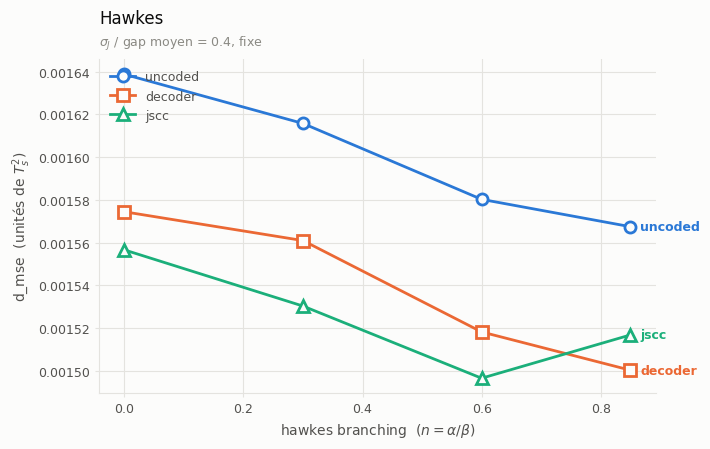

In [12]:
def fig_distortion(rows, metric="d_mse", title="Hawkes"):
    fig, ax = plt.subplots(figsize=(7.2, 4.6), facecolor=SURFACE)
    for mode in MODES:
        pts = sorted([r for r in rows if r["mode"] == mode],
                     key=lambda r: r["hawkes_branching"])
        if not pts:
            continue
        colour, marker = MODE_STYLE[mode]
        xs = [r["hawkes_branching"] for r in pts]
        ys = [r[metric] for r in pts]
        ax.plot(xs, ys, color=colour, lw=2.0, marker=marker, ms=8, mew=2.0,
                mfc=SURFACE, mec=colour, zorder=5, label=mode)
        ax.annotate(mode, (xs[-1], ys[-1]), textcoords="offset points",
                    xytext=(7, 0), color=colour, fontsize=9, fontweight="bold",
                    va="center")
    unit = "$T_s^2$"
    style(ax, "hawkes branching  ($n = \\alpha/\\beta$)", f"{metric}  (unités de {unit})",
          title, f"$\\sigma_J$ / gap moyen = {SIGMA_RATIO:g}, fixe")
    legend(ax)
    fig.tight_layout()
    return fig


fig_distortion(HAWKES_ROWS)
plt.show()

## Le mapping des écarts (éq. 12) — qu'apprend l'encodeur ?

Pour chaque `branching`, on trace `g_i` (l'écart source) contre `g_i^{(X)}` (l'écart après
encodage) : les temps de bin sélectionnés par l'encodeur, dans l'ordre. Comme `N_X = N_S` est
garanti par construction et qu'un raster est ordonné par indice de bin, le `i`-ième écart du code
correspond au `i`-ième écart de la source pour chaque bloc (même longueur des deux côtés). Si
l'encodeur avait convergé vers l'identité, tous les points seraient sur la diagonale. On regarde
aussi le facteur `g_i^{(X)}/g_i` en fonction de la taille de l'écart source, pour voir si les
petits écarts (intra-rafale) et les grands écarts (silences) sont traités différemment.

In [ ]:
def fig_gap_mapping(models, branchings, n_blocks=GAPMAP_N_BLOCKS, seed=GAPMAP_SEED):
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6), facecolor=SURFACE)
    colours = plt.get_cmap("viridis")(np.linspace(0.15, 0.85, len(branchings)))
    lim = 0.0
    for colour, b in zip(colours, branchings):
        model, cfg, _ = models[(b, "jscc")]
        rng = np.random.default_rng(seed)
        with torch.no_grad():
            r_source, _ = sample_source(cfg, n_blocks, rng)
            r_code = model.encoder(r_source)
        times_s = raster_to_times(r_source, cfg)
        times_x = raster_to_times(r_code, cfg)
        # N_X = N_S garanti par construction : même longueur des deux côtés,
        # bloc par bloc, donc la concaténation aligne bien gap i <-> gap i.
        gs = np.concatenate([np.diff(t, prepend=0.0) for t in times_s]) / cfg.mean_gap
        gx = np.concatenate([np.diff(t, prepend=0.0) for t in times_x]) / cfg.mean_gap
        lim = max(lim, gs.max(initial=0.0), gx.max(initial=0.0))
        axes[0].scatter(gs, gx, s=4, color=colour, alpha=0.35, lw=0,
                        label=f"branching = {b:g}")
        mult = gx / np.clip(gs, 1e-6, None)
        order = np.argsort(gs)
        axes[1].plot(gs[order], mult[order], color=colour, lw=1.2, alpha=0.8,
                     label=f"branching = {b:g}")

    axes[0].plot([0, lim], [0, lim], color=INK, lw=1.5, ls=(0, (4, 3)), zorder=4)
    axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
    style(axes[0], "$g_i$ / gap moyen", "$g_i^{(X)}$ / gap moyen",
          "Application des écarts", "tirets : identité")
    legend(axes[0])

    axes[1].axhline(1.0, color=INK, lw=1.5, ls=(0, (4, 3)), zorder=4)
    axes[1].set_xscale("log")
    style(axes[1], "$g_i$ / gap moyen (log)", "facteur appris  $g_i^{(X)} / g_i$",
          "Le facteur dépend-il de la taille du gap ?", "tirets : facteur 1 (identité)")
    legend(axes[1])
    fig.tight_layout()
    return fig


fig_gap_mapping(HAWKES_MODELS, [0.0, 0.3, 0.6, 0.85])
plt.show()

## Une réalisation à travers la chaîne

Chaque étage (source, code, sortie canal, reconstruction) est un raster ; on affiche les temps de
bin correspondant aux positions à `1`. Répété sur plusieurs blocs pour voir la variabilité de
`N_S` (nombre d'événements réels) d'un bloc à l'autre, puisque N n'est plus fixé par la source.

In [ ]:
def fig_realisation(models, b, mode="jscc", block=0, seed=REALISATION_SEED):
    model, cfg, _ = models[(b, mode)]
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    with torch.no_grad():
        r_source, _ = sample_source(cfg, block + 1, rng)
        out = model(r_source, gen=gen)
    S = raster_to_times(r_source, cfg)[block]
    X = raster_to_times(out["r_code"], cfg)[block]
    Y = raster_to_times(out["r_channel"], cfg)[block]
    H = raster_to_times(out["r_hat"], cfg)[block]

    rows = [("$S$  source", S, INK), ("$X$  mot de code", X, C_UNCODED),
            ("$Y$  sortie canal", Y, C_DECODER), ("$\\hat{S}$  reconstruction", H, C_JSCC)]
    fig, ax = plt.subplots(figsize=(9.2, 4.0), facecolor=SURFACE)
    for k, (name, vals, colour) in enumerate(rows):
        y0 = len(rows) - 1 - k
        ax.eventplot([vals], colors=colour, lineoffsets=y0, linelengths=0.52,
                     linewidths=2.4, zorder=6)
        ax.text(-0.015, y0, name, transform=ax.get_yaxis_transform(), color=colour,
                fontsize=9, fontweight="bold", ha="right", va="center")
    for xv in (0.0, cfg.Tc):
        ax.axvline(xv, color=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=2)
    sub = (f"mode = {mode}, branching = {b:g}, bloc {block}, "
           f"N_S={len(S)}, N_X={len(X)}, N_Y={len(Y)}, N_Ŝ={len(H)}, "
           f"tirets : $[0, T_c]$")
    ax.set_ylim(-0.6, 3.6); ax.set_yticks([])
    style(ax, "temps  (unités de $T_s$)", "", "Une réalisation à travers la chaîne", sub)
    fig.tight_layout()
    return fig


for blk in REALISATION_BLOCKS:
    fig_realisation(HAWKES_MODELS, 0.85, mode="jscc", block=blk)
    plt.show()

for m in MODES:
    fig_realisation(HAWKES_MODELS, 0.85, mode=m, block=REALISATION_BLOCKS[0])
    plt.show()

## Limites et choix à assumer

### Difficulté d'optimisation résiduelle (à discuter avec l'encadrant)

Même après avoir corrigé les deux ruptures de gradient (canal, seuil LIF) et être passé à la
vraie distorsion du PDF, `decoder` et `jscc` restent nettement pires que `uncoded` sur le budget
testé -- `decoder` seul devrait pourtant pouvoir apprendre l'identité et au moins égaler `uncoded`.
Causes probables, cumulatives :

1. **Déroulement récurrent long** (`T_bins=128` pas) à travers un réseau à surrogate gradient :
   les gradients à travers de longues séquences récurrentes sont connus pour s'atténuer/se
   bruiter (comme pour les RNN classiques), et l'erreur d'approximation du surrogate arctan
   s'accumule sur les 128 pas.
2. **Deux mécanismes top-N empilés** (encodeur, décodeur), chacun un straight-through
   (sélection dure en avant, gradient lissé en arrière) -- une approximation par mécanisme, et
   elles se combinent en série à travers le canal.
3. **La distorsion fidèle au PDF ajoute une troisième couche d'approximation** : l'estimation
   molle de `T̂_i` (noyau gaussien sur le rang cumulé, `temp_rank`) a son propre compromis
   biais/variance -- mal réglée, elle peut donner un gradient qui pointe dans une direction
   légèrement fausse (cf. le piège p=0.5 déjà trouvé et corrigé, qui montre que ce genre d'erreur
   silencieuse est facile à introduire ici).
4. **Le taux d'apprentissage d'origine (3e-3, hérité de la version continue du notebook) fait
   diverger cette loss** : bonne au début (~step 150), elle explose ensuite vers un plateau 5 à
   15x pire. Un taux 10x plus bas (3e-4) stabilise sans totalement résoudre le problème.
5. Le PDF anticipe explicitement ce genre de difficulté ("Optimization issue: be careful about
   possible optimization issues") -- sa section "Step 3" (modèle minimal à deux événements)
   suggère précisément de réduire à l'échelle la plus petite possible pour isoler le mécanisme
   avant de repasser à l'échelle complète, une piste naturelle pour la suite.

### Autres limites assumées

- **Collisions de bins non négligeables**, surtout en régime rafale (`frac_source_collision` et
  `frac_channel_collision`, suivies dans le tableau) : la source Hawkes a une proportion notable
  d'écarts plus petits que `bin_width`, y compris à `T_bins` bien plus grand que 128 (mesuré
  jusqu'à `T_bins=1024`, cf. markdown d'intro). Conséquence assumée du passage à un vrai raster
  de spikes, pas un bug à corriger dans ce notebook.
- **Un seul seed par point** du sweep : les écarts entre `decoder` et `jscc` sont à lire avec
  cette réserve — pas de barre d'erreur ici.
- **`sigma_J` fixe** pour tout le sweep en branching : un sweep croisé (branching x sigma) donnerait
  une vue plus complète, mais multiplie le coût par la taille de la seconde grille.
- Le SNN reste volontairement **à une seule couche cachée feed-forward** — un choix de simplicité,
  pas une limite de capacité démontrée.

## Comparaison rapide entre types de source (Poisson, renouvellement Gamma, Hawkes)

Le PDF propose une progression : **Step 1** (Poisson, la source la plus "aléatoire", où l'encodeur
pourrait raisonnablement converger vers l'identité), **Step 2** (renouvellement, eq. 10 :
`W_i ~ Gamma(k, mean_gap/k)`, plus prévisible quand `k` grandit), et l'extension Hawkes de ce
notebook (mémoire multi-événements). Même pipeline exact (SNN, canal, top-N, distorsion fidèle au
PDF) que plus haut, juste la fonction source qui change — pour un budget d'entraînement réduit
(`800` pas au lieu de `3000`, pour rester rapide) : les chiffres sont donc indicatifs, pas le
résultat final du sweep principal.

In [ ]:
def sample_poisson(cfg: Config, batch: int, rng: np.random.Generator):
    """Processus de Poisson homogène = renouvellement exponentiel i.i.d.
    (PDF, Step 1). Même logique fenêtre Ts fixe / N aléatoire que sample_source."""
    r = torch.zeros(batch, cfg.T_bins, dtype=torch.float32, device=DEVICE)
    n_raw = np.zeros(batch, dtype=np.int64)
    for b in range(batch):
        t, times = 0.0, []
        while len(times) < cfg.max_events_cap:
            t += rng.exponential(cfg.mean_gap)
            if t >= cfg.Ts:
                break
            times.append(t)
        n_raw[b] = len(times)
        if times:
            idx = np.minimum((np.array(times) / cfg.bin_width).astype(np.int64), cfg.T_bins - 1)
            r[b, idx] = 1.0
    return r, n_raw


def sample_gamma_renewal(cfg: Config, batch: int, rng: np.random.Generator, k: float):
    """Renouvellement Gamma, W_i ~ Gamma(k, mean_gap/k) i.i.d. (PDF eq. 10).
    k=1 -> exponentiel (Poisson) ; k grand -> timing de plus en plus régulier."""
    r = torch.zeros(batch, cfg.T_bins, dtype=torch.float32, device=DEVICE)
    n_raw = np.zeros(batch, dtype=np.int64)
    for b in range(batch):
        t, times = 0.0, []
        while len(times) < cfg.max_events_cap:
            t += rng.gamma(shape=k, scale=cfg.mean_gap / k)
            if t >= cfg.Ts:
                break
            times.append(t)
        n_raw[b] = len(times)
        if times:
            idx = np.minimum((np.array(times) / cfg.bin_width).astype(np.int64), cfg.T_bins - 1)
            r[b, idx] = 1.0
    return r, n_raw


def quick_train_eval(sampler, mode: str, cfg: Config, steps: int = 800, seed: int = 2):
    """Comme train_system/measure, mais paramétré par la fonction source
    (sampler(cfg, batch, rng) -> (r, n_raw)) -- même pipeline (SNN, canal,
    top-N, distorsion fidèle au PDF) que le sweep Hawkes, pour comparer
    rapidement plusieurs types de source."""
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed + 1)
    model = System(cfg, mode).to(DEVICE)
    if model.n_params > 0:
        opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
        sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=cfg.lr,
                                                    total_steps=steps, pct_start=0.1)
        for step in range(steps):
            r_source, _ = sampler(cfg, cfg.batch, rng)
            out = model(r_source, gen=gen)
            loss, _, _ = pdf_distortion(r_source, out, cfg)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            sched.step()
    with torch.no_grad():
        r_eval, n_raw = sampler(cfg, cfg.eval_batch, np.random.default_rng(9999))
        gen_eval = torch.Generator(device=DEVICE).manual_seed(10000)
        out = model(r_eval, gen=gen_eval)
        n_s = r_eval.sum(dim=1)
        n_hat = out["r_hat"].sum(dim=1)
        N_max = max(int(n_s.max().item()), 1)
        t_true, mask_true = exact_rank_times(r_eval, cfg, N_max)
        t_hat, _ = exact_rank_times(out["r_hat"], cfg, N_max)
        n_match = torch.minimum(n_s, n_hat)
        idx = torch.arange(N_max, device=DEVICE).unsqueeze(0)
        mask_match = (idx < n_match.unsqueeze(1)) & mask_true
        block_d = ((t_true - t_hat) ** 2 * mask_match.float()).sum(dim=1) / n_match.clamp(min=1).float()
        coll = float((torch.as_tensor(n_raw) != n_s).float().mean())
    return model, {"d_mse": float(block_d.mean()), "mean_n_s": float(n_s.mean()),
                   "frac_source_collision": coll, "mode": mode}

In [ ]:
QUICK_STEPS = 800
SOURCE_SAMPLERS = {
    "poisson": lambda cfg, b, rng: sample_poisson(cfg, b, rng),
    "gamma_k4": lambda cfg, b, rng: sample_gamma_renewal(cfg, b, rng, k=4.0),
    "hawkes": lambda cfg, b, rng: sample_source(cfg, b, rng),  # CFG.hawkes_branching par défaut (0.5)
}

QUICK_ROWS, QUICK_MODELS = [], {}
for name, sampler in SOURCE_SAMPLERS.items():
    for mode in MODES:
        model, m = quick_train_eval(sampler, mode, CFG, steps=QUICK_STEPS)
        m["source"] = name
        QUICK_ROWS.append(m)
        QUICK_MODELS[(name, mode)] = model
        print(f"{name:10s} {mode:8s}  d_mse={m['d_mse']:.4f}  mean_n_s={m['mean_n_s']:.1f}"
              f"  frac_collision={m['frac_source_collision']:.3f}", flush=True)

show_table(QUICK_ROWS, cols=["source", "mode", "d_mse", "mean_n_s", "frac_source_collision"],
           title=f"Comparaison rapide de sources (steps={QUICK_STEPS}, T_bins={CFG.T_bins})")

In [ ]:
def fig_realisation_generic(sampler, model, cfg: Config, title_prefix: str,
                             block: int = 0, seed: int = REALISATION_SEED):
    """Comme fig_realisation, mais paramétré par une fonction source
    quelconque plutôt que par (HAWKES_MODELS, branching) -- pour comparer la
    chaîne complète S -> X -> Y -> Ŝ entre types de source."""
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    with torch.no_grad():
        r_source, _ = sampler(cfg, block + 1, rng)
        out = model(r_source, gen=gen)
    S = raster_to_times(r_source, cfg)[block]
    X = raster_to_times(out["r_code"], cfg)[block]
    Y = raster_to_times(out["r_channel"], cfg)[block]
    H = raster_to_times(out["r_hat"], cfg)[block]

    rows = [("$S$  source", S, INK), ("$X$  mot de code", X, C_UNCODED),
            ("$Y$  sortie canal", Y, C_DECODER), ("$\\hat{S}$  reconstruction", H, C_JSCC)]
    fig, ax = plt.subplots(figsize=(9.2, 4.0), facecolor=SURFACE)
    for k, (name, vals, colour) in enumerate(rows):
        y0 = len(rows) - 1 - k
        ax.eventplot([vals], colors=colour, lineoffsets=y0, linelengths=0.52,
                     linewidths=2.4, zorder=6)
        ax.text(-0.015, y0, name, transform=ax.get_yaxis_transform(), color=colour,
                fontsize=9, fontweight="bold", ha="right", va="center")
    for xv in (0.0, cfg.Tc):
        ax.axvline(xv, color=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=2)
    sub = (f"source = {title_prefix}, mode = jscc, bloc {block}, "
           f"N_S={len(S)}, N_X={len(X)}, N_Y={len(Y)}, N_Ŝ={len(H)}, tirets : $[0, T_c]$")
    ax.set_ylim(-0.6, 3.6); ax.set_yticks([])
    style(ax, "temps  (unités de $T_s$)", "", "Une réalisation à travers la chaîne", sub)
    fig.tight_layout()
    return fig


for name, sampler in SOURCE_SAMPLERS.items():
    fig_realisation_generic(sampler, QUICK_MODELS[(name, "jscc")], CFG, title_prefix=name)
    plt.show()